
Diversity Score Summary and Percentage Changes (from previous p):
p      max-min_avg     avg-div_avg  %Δ max-min   %Δ avg-div  
-----------------------------------------------------------------
1.0    0.00074891      0.12         0.00%        0.00%        0.00%       
2.0    0.00131354      0.13         75.39%       1.63%        38.51%      
3.0    0.00070015      0.13         -46.70%      0.56%        -23.07%     
4.0    0.00048010      0.13         -31.43%      0.37%        -15.53%     
5.0    0.00039230      0.13         -18.29%      -0.01%       -9.15%      


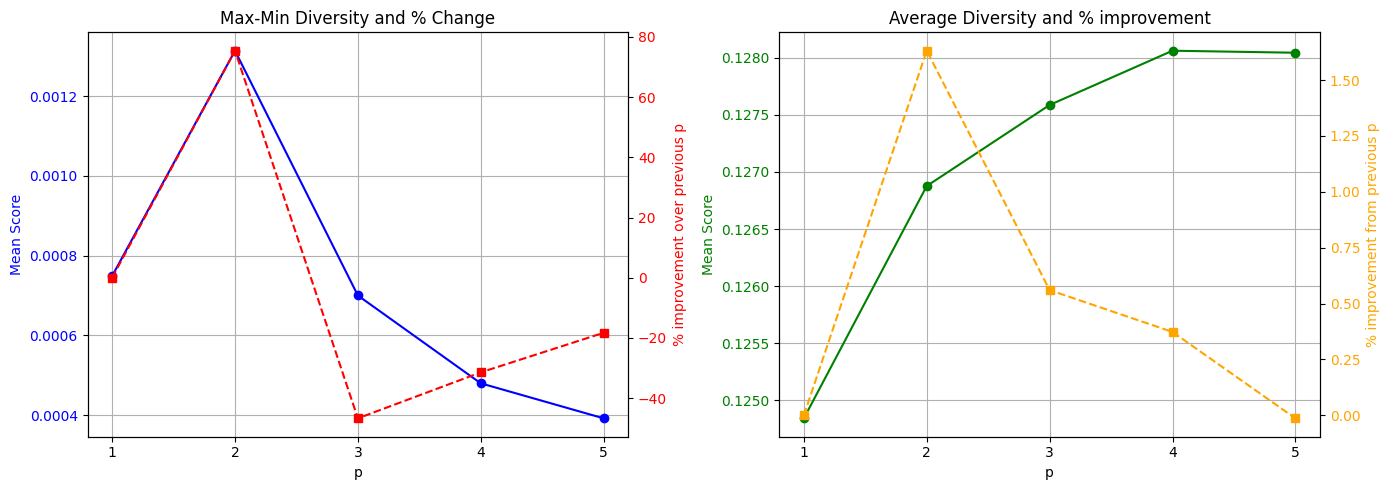

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Load and preprocess
df = pd.read_csv("stats/santos_benchmark_p_analysis.csv")
df = pd.read_csv("stats/ugen_benchmark_p_analysis.csv")
df = df[df['with_query_flag'] == 'mix'] #uses appropriate diversity metrics, other options are yes or no.
# with_query_flag == "yes" will compute diversity also on the basis of distance between query tuples.
# with_query_flag == "no" will compute only among the data lake tuples.
# with_query_flag == "mix" computes withing data lake tuples and between query and data lake tuples. 
summary = df.groupby('algorithm')[['max-min_div_score', 'avg_div_score']].mean().reset_index()
summary['p'] = summary['algorithm'].str.extract(r'p=(\d+)').astype(float)
summary = summary.sort_values('p').reset_index(drop=True)

# Compute % change from previous p
summary['%_change_maxmin'] = summary['max-min_div_score'].pct_change().fillna(0) * 100
summary['%_change_avgdiv'] = summary['avg_div_score'].pct_change().fillna(0) * 100
summary['%_combined_improve'] = (summary['%_change_maxmin'] + summary['%_change_avgdiv']) / 2

# Print table
print("\nDiversity Score Summary and Percentage Changes (from previous p):")
print(f"{'p':<6} {'max-min_avg':<15} {'avg-div_avg':<12} {'%Δ max-min':<12} {'%Δ avg-div':<12}")
print("-" * 65)
for _, row in summary.iterrows():
    change_maxmin = f"{row['%_change_maxmin']:.2f}%" if pd.notna(row['%_change_maxmin']) else "—"
    change_avgdiv = f"{row['%_change_avgdiv']:.2f}%" if pd.notna(row['%_change_avgdiv']) else "—"
    change_combine = f"{row['%_combined_improve']:.2f}%" if pd.notna(row['%_combined_improve']) else "—"
    print(f"{row['p']:<6.1f} {row['max-min_div_score']:<15.8f} {row['avg_div_score']:<12.2f} {change_maxmin:<12} {change_avgdiv:<12} {change_combine:<12}")

# Plotting both score and % change
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot for Max-Min Diversity ---
ax1 = axs[0]
ax2 = ax1.twinx()
ax1.plot(summary['p'], summary['max-min_div_score'], '-o', label='Max-Min Diversity', color='blue')
ax2.plot(summary['p'], summary['%_change_maxmin'], '--s', label='% Change', color='red')


ax1.set_title('Max-Min Diversity and % Change')
ax1.set_xlabel('p')
ax1.set_ylabel('Mean Score', color='blue')
ax2.set_ylabel(r'% improvement over previous p', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax1.grid(True)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

# --- Plot for Avg Diversity ---
ax3 = axs[1]
ax4 = ax3.twinx()
ax3.plot(summary['p'], summary['avg_div_score'], '-o', label='Avg Diversity', color='green')
ax4.plot(summary['p'], summary['%_change_avgdiv'], '--s', label='% Change', color='orange')

ax3.set_title(r'Average Diversity and % improvement')
ax3.set_xlabel('p')
ax3.set_ylabel('Mean Score', color='green')
ax4.set_ylabel(r'% improvement from previous p', color='orange')
ax3.tick_params(axis='y', labelcolor='green')
ax4.tick_params(axis='y', labelcolor='orange')
ax4.xaxis.set_major_locator(MaxNLocator(integer=True))

ax3.grid(True)
# plt.legend()
plt.tight_layout()
plt.show()



Diversity Score Summary and Percentage Changes (from previous p):
p      max-min_avg     avg-div_avg  %Δ max-min   %Δ avg-div  
-----------------------------------------------------------------
1.0    0.00074891      0.12         0.00%        0.00%        0.00%       
2.0    0.00131354      0.13         75.39%       1.63%        38.51%      
3.0    0.00070015      0.13         -46.70%      0.56%        -23.07%     
4.0    0.00048010      0.13         -31.43%      0.37%        -15.53%     
5.0    0.00039230      0.13         -18.29%      -0.01%       -9.15%      


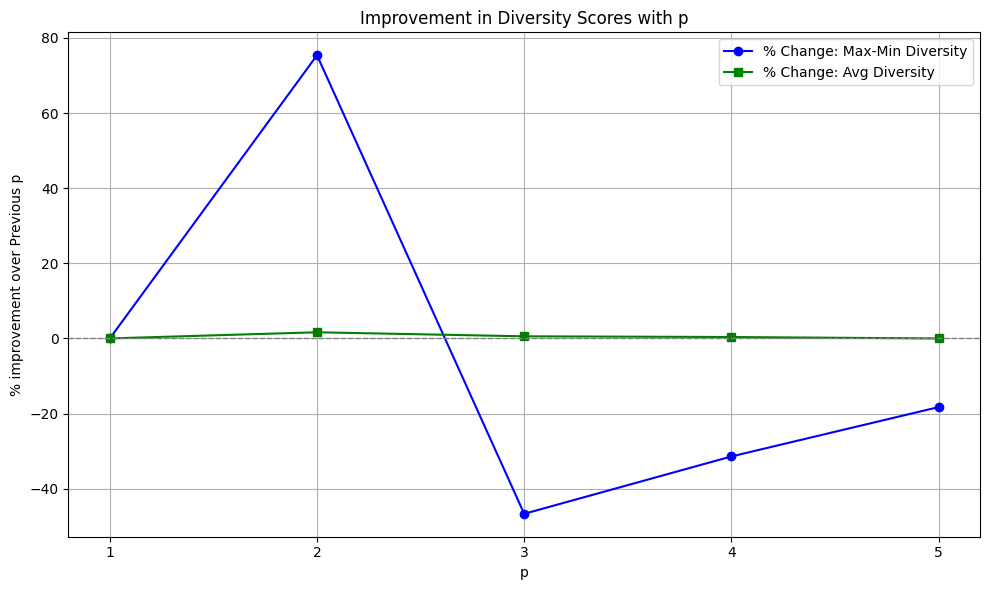

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and preprocess
df = pd.read_csv("stats/santos_benchmark_p_analysis.csv")
df = pd.read_csv("stats/ugen_benchmark_p_analysis.csv")

df = df[df['with_query_flag'] == 'mix']

# Compute mean scores
summary = df.groupby('algorithm')[['max-min_div_score', 'avg_div_score']].mean().reset_index()
summary['p'] = summary['algorithm'].str.extract(r'p=(\d+)').astype(float)
summary = summary.sort_values('p').reset_index(drop=True)

# Compute % change from previous p and set p=1 to 0%
summary['%_change_maxmin'] = summary['max-min_div_score'].pct_change().fillna(0) * 100
summary['%_change_avgdiv'] = summary['avg_div_score'].pct_change().fillna(0) * 100
summary['%_combined_improve'] = (summary['%_change_maxmin'] + summary['%_change_avgdiv']) / 2

# Print table
print("\nDiversity Score Summary and Percentage Changes (from previous p):")
print(f"{'p':<6} {'max-min_avg':<15} {'avg-div_avg':<12} {'%Δ max-min':<12} {'%Δ avg-div':<12}")
print("-" * 65)
for _, row in summary.iterrows():
    change_maxmin = f"{row['%_change_maxmin']:.2f}%" if pd.notna(row['%_change_maxmin']) else "—"
    change_avgdiv = f"{row['%_change_avgdiv']:.2f}%" if pd.notna(row['%_change_avgdiv']) else "—"
    change_combine = f"{row['%_combined_improve']:.2f}%" if pd.notna(row['%_combined_improve']) else "—"
    print(f"{row['p']:<6.1f} {row['max-min_div_score']:<15.8f} {row['avg_div_score']:<12.2f} {change_maxmin:<12} {change_avgdiv:<12} {change_combine:<12}")



# Plotting
plt.figure(figsize=(10, 6))
plt.plot(summary['p'], summary['%_change_maxmin'], '-o', label='% Change: Max-Min Diversity', color='blue')
plt.plot(summary['p'], summary['%_change_avgdiv'], '-s', label='% Change: Avg Diversity', color='green')

# Labels and grid
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('p')
plt.ylabel(r'% improvement over Previous p')
plt.title('Improvement in Diversity Scores with p')
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True)
plt.tight_layout()
plt.show()
